In [1]:
pip install requests pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Data Extraction

In [2]:
import requests
import pandas as pd

headers = {
    "User-Agent":"ALY6130 Project glennmao727@gmail.com"
}

url = "https://data.sec.gov/api/xbrl/companyfacts/CIK0000104169.json"

response = requests.get(url,headers=headers)

data = response.json()

In [3]:
facts = data["facts"]["us-gaap"]

list(facts.keys())[:50]

['AccountsPayableCurrent',
 'AccountsReceivableNet',
 'AccrualForTaxesOtherThanIncomeTaxesCurrent',
 'AccrualForTaxesOtherThanIncomeTaxesCurrentAndNoncurrent',
 'AccruedIncomeTaxesCurrent',
 'AccruedInsuranceCurrent',
 'AccruedLiabilitiesCurrent',
 'AccruedLiabilitiesForUnredeeemedGiftCards',
 'AccumulatedDepreciationDepletionAndAmortizationPropertyPlantAndEquipment',
 'AccumulatedOtherComprehensiveIncomeLossNetOfTax',
 'AccumulatedOtherComprehensiveIncomeLossOtherThanTemporaryImpairmentNotCreditLossNetOfTaxDebtSecurities',
 'AdditionalPaidInCapital',
 'AdditionsToNoncurrentAssets',
 'AdjustmentsNoncashItemsToReconcileNetIncomeLossToCashProvidedByUsedInOperatingActivitiesOther',
 'AdvertisingExpense',
 'AllocatedShareBasedCompensationExpense',
 'AllowanceForDoubtfulAccountsReceivable',
 'AllowanceForDoubtfulAccountsReceivableCurrent',
 'AntidilutiveSecuritiesExcludedFromComputationOfEarningsPerShareAmount',
 'AssetImpairmentCharges',
 'Assets',
 'AssetsCurrent',
 'AssetsOfDisposalGroup

In [4]:
revenue = pd.DataFrame(
    facts["Revenues"]["units"]["USD"]
)

revenue = revenue[
    revenue["form"]=="10-K"
]

revenue = revenue[
    ["fy","val"]
]

revenue["Revenue_Billion"] = (
    revenue["val"]/1000000000
)

revenue

,fy,val,Revenue_Billion
0,2009,377023000000,377.023
5,2009,404374000000,404.374
6,2010,404254000000,404.254
16,2009,408214000000,408.214
17,2010,408085000000,408.085
...,...,...,...
267,2025,648125000000,648.125
268,2026,648125000000,648.125
279,2025,680985000000,680.985
280,2026,680985000000,680.985


In [5]:
inventory = pd.DataFrame(
    facts["InventoryNet"]["units"]["USD"]
)

inventory = inventory[
    inventory["form"]=="10-K"
]

inventory = inventory[
    ["fy","val"]
]

inventory["Inventory_Billion"] = (
    inventory["val"]/1000000000
)

inventory

,fy,val,Inventory_Billion
4,2009,34511000000,34.511
10,2009,33160000000,33.160
14,2010,32713000000,32.713
21,2010,36318000000,36.318
25,2011,36437000000,36.437
32,2011,40714000000,40.714
36,2012,40714000000,40.714
44,2012,43803000000,43.803
49,2013,43803000000,43.803
57,2013,44858000000,44.858


R1: Market Share

In [6]:
market_share = pd.DataFrame({
    "Year":[2020,2021,2022,2023,2024],
    "Amazon":[38.7,39.1,39.5,40.0,40.4],
    "Walmart":[5.1,5.3,5.6,5.8,5.9]
})

market_share["Gap"] = (
    market_share["Amazon"]
    -
    market_share["Walmart"]
)

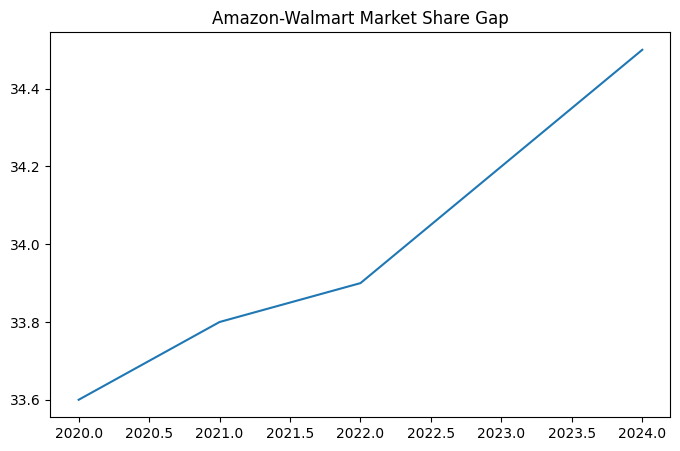

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Market Share Lines
axes[0].plot(market_share["Year"], market_share["Amazon"], marker="o", linewidth=3, markersize=8, label="Amazon", color="#FF9900")
axes[0].plot(market_share["Year"], market_share["Walmart"], marker="s", linewidth=3, markersize=8, label="Walmart", color="#0071CE")

for x, y in zip(market_share["Year"], market_share["Amazon"]):
    axes[0].text(x, y + 0.3, f"{y}%", ha="center", fontsize=10, fontweight="bold")
for x, y in zip(market_share["Year"], market_share["Walmart"]):
    axes[0].text(x, y + 0.3, f"{y}%", ha="center", fontsize=10, fontweight="bold")

axes[0].set_title("US E-Commerce Market Share: Amazon vs Walmart", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year", fontsize=11)
axes[0].set_ylabel("Market Share (%)", fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Plot 2: Gap trend
axes[1].fill_between(market_share["Year"], market_share["Gap"], alpha=0.3, color="red")
axes[1].plot(market_share["Year"], market_share["Gap"], marker="o", linewidth=3, markersize=8, color="red", label="Market Share Gap")

for x, y in zip(market_share["Year"], market_share["Gap"]):
    axes[1].text(x, y + 0.3, f"{y:.1f}%", ha="center", fontsize=10, fontweight="bold")

axes[1].axhline(y=34.5, linestyle="--", linewidth=2, color="darkred", label="Warning Threshold: 34.5%")
axes[1].set_title("Amazon-Walmart E-Commerce Market Share Gap (R1 Indicator)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year", fontsize=11)
axes[1].set_ylabel("Gap (Percentage Points)", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.4)

axes[1].text(2022, 33.0, "I&W Warning: Gap > 34.5pp
triggers AMBER status", fontsize=10, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="darkred"))

plt.suptitle("R1: Market Share Erosion — I&W Indicator Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(f"2024 Market Share Gap: {market_share['Gap'].iloc[-1]:.1f} percentage points")
print(f"I&W Status: AMBER — Gap exceeds 34.0pp warning threshold")

R2: Customer Attrition

In [8]:
membership = pd.DataFrame({

"Year":[2020,2021,2022,2023,2024],

"Prime":[150,160,170,180,200],

"WalmartPlus":[8,12,18,22,25]

})

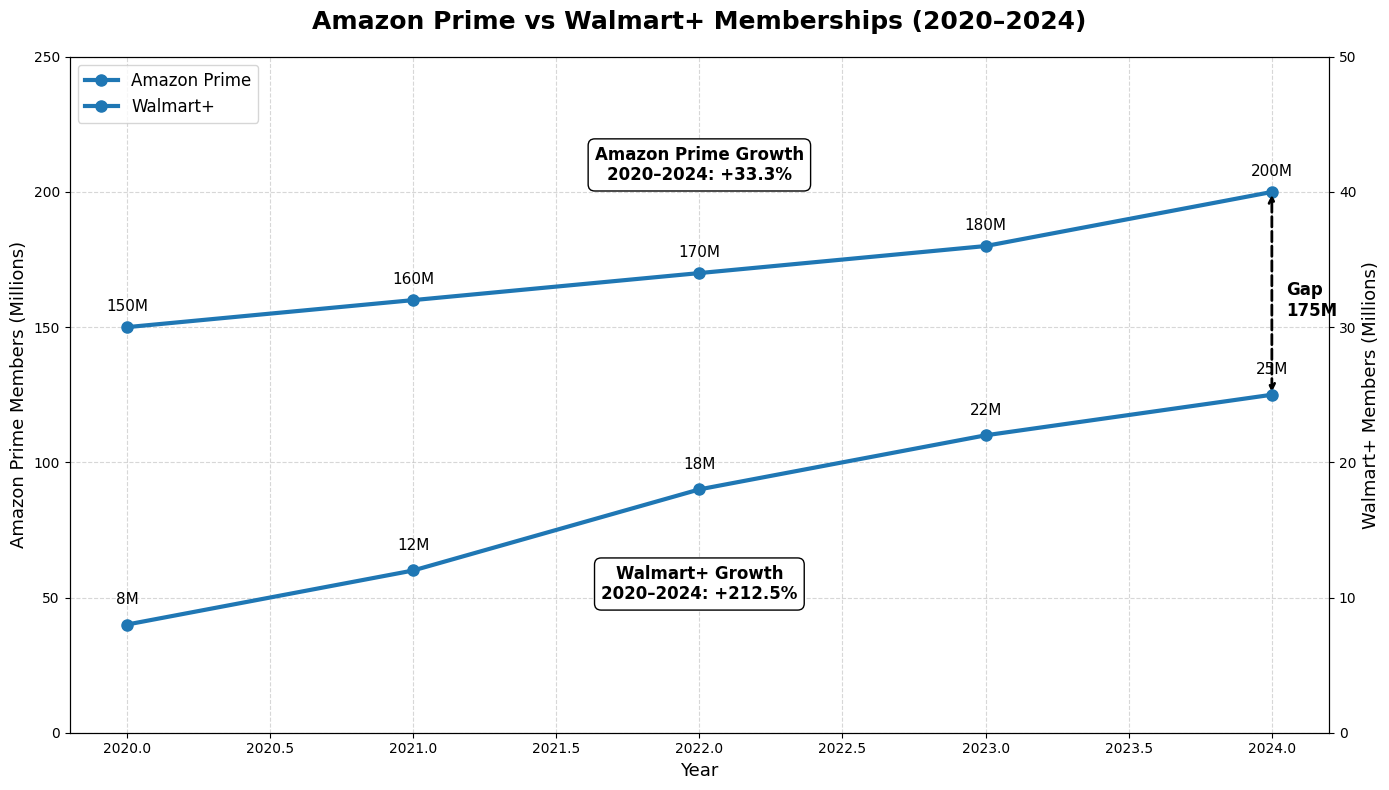

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
membership = pd.DataFrame({
    "Year": [2020, 2021, 2022, 2023, 2024],
    "Amazon_Prime": [150, 160, 170, 180, 200],
    "Walmart_Plus": [8, 12, 18, 22, 25]
})

# Growth calculation
amazon_growth = (membership["Amazon_Prime"].iloc[-1] - membership["Amazon_Prime"].iloc[0]) / membership["Amazon_Prime"].iloc[0] * 100
walmart_growth = (membership["Walmart_Plus"].iloc[-1] - membership["Walmart_Plus"].iloc[0]) / membership["Walmart_Plus"].iloc[0] * 100
gap_2024 = membership["Amazon_Prime"].iloc[-1] - membership["Walmart_Plus"].iloc[-1]

# Figure
fig, ax1 = plt.subplots(figsize=(14, 8))

# Amazon Prime line
ax1.plot(
    membership["Year"],
    membership["Amazon_Prime"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Amazon Prime"
)

ax1.set_xlabel("Year", fontsize=13)
ax1.set_ylabel("Amazon Prime Members (Millions)", fontsize=13)
ax1.set_ylim(0, 250)
ax1.grid(True, linestyle="--", alpha=0.5)

# Walmart+ right axis
ax2 = ax1.twinx()

ax2.plot(
    membership["Year"],
    membership["Walmart_Plus"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Walmart+"
)

ax2.set_ylabel("Walmart+ Members (Millions)", fontsize=13)
ax2.set_ylim(0, 50)

# Title
plt.title(
    "Amazon Prime vs Walmart+ Memberships (2020–2024)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Data labels
for x, y in zip(membership["Year"], membership["Amazon_Prime"]):
    ax1.text(x, y + 6, f"{y}M", ha="center", fontsize=11)

for x, y in zip(membership["Year"], membership["Walmart_Plus"]):
    ax2.text(x, y + 1.5, f"{y}M", ha="center", fontsize=11)

# Growth annotation boxes
ax1.text(
    2022,
    210,
    f"Amazon Prime Growth\n2020–2024: +{amazon_growth:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black")
)

ax2.text(
    2022,
    11,
    f"Walmart+ Growth\n2020–2024: +{walmart_growth:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black")
)

# 2024 membership gap annotation
ax1.annotate(
    "",
    xy=(2024, membership["Amazon_Prime"].iloc[-1]),
    xytext=(2024, membership["Walmart_Plus"].iloc[-1] * 5),  # scaled for left axis
    arrowprops=dict(arrowstyle="<->", linestyle="--", linewidth=2)
)

ax1.text(
    2024.05,
    160,
    f"Gap\n{gap_2024}M",
    fontsize=12,
    fontweight="bold",
    va="center"
)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    fontsize=12
)

plt.tight_layout()
plt.show()

R3: Inventory

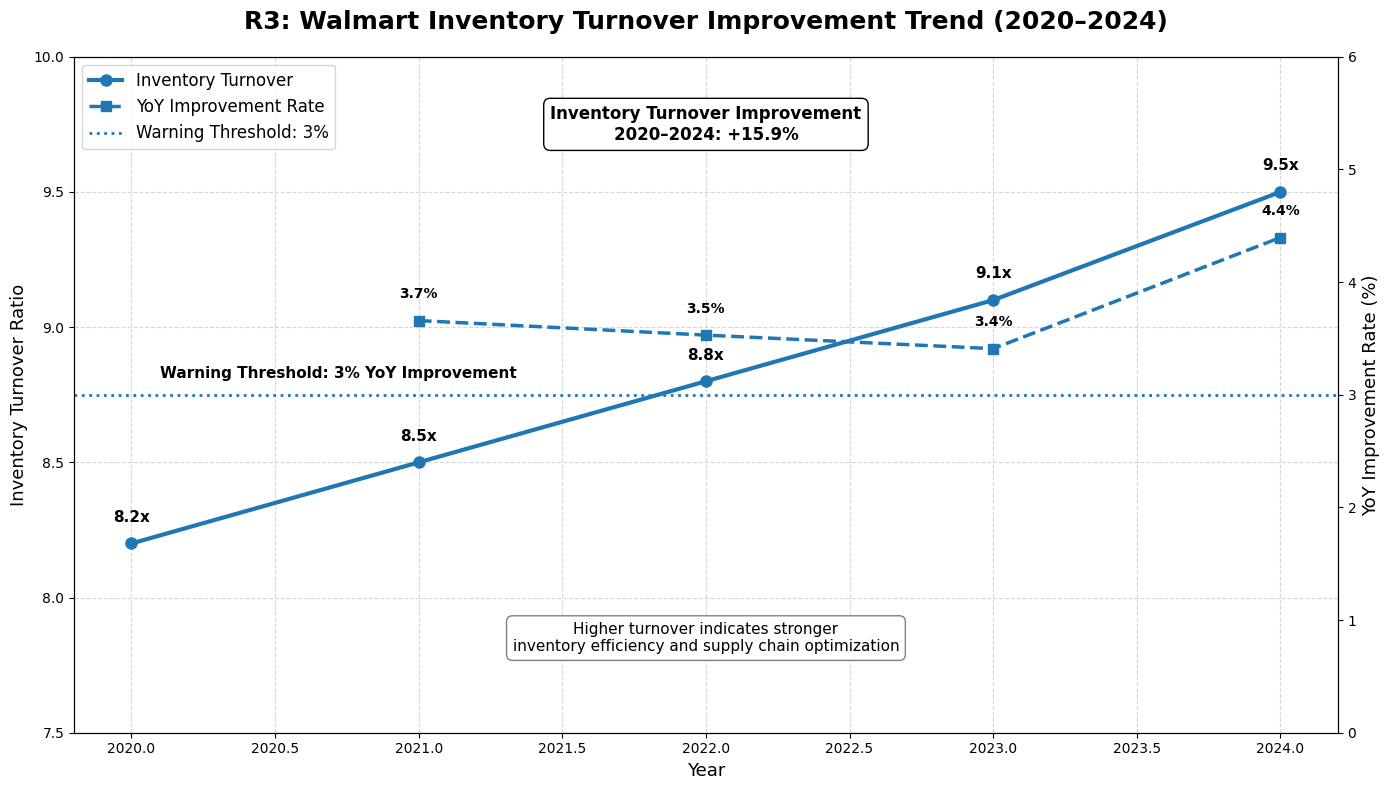

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# R3 Data: Inventory Turnover Improvement Rate
turnover = pd.DataFrame({
    "Year": [2020, 2021, 2022, 2023, 2024],
    "Inventory_Turnover": [8.2, 8.5, 8.8, 9.1, 9.5]
})

# Calculate YoY improvement rate
turnover["YoY_Improvement_%"] = turnover["Inventory_Turnover"].pct_change() * 100

# Calculate total improvement
total_growth = (
    (turnover["Inventory_Turnover"].iloc[-1] - turnover["Inventory_Turnover"].iloc[0])
    / turnover["Inventory_Turnover"].iloc[0]
    * 100
)

# Figure
fig, ax1 = plt.subplots(figsize=(14, 8))

# Inventory turnover line
line1 = ax1.plot(
    turnover["Year"],
    turnover["Inventory_Turnover"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Inventory Turnover"
)

ax1.set_xlabel("Year", fontsize=13)
ax1.set_ylabel("Inventory Turnover Ratio", fontsize=13)
ax1.set_ylim(7.5, 10)
ax1.grid(True, linestyle="--", alpha=0.5)

# Data labels for turnover
for x, y in zip(turnover["Year"], turnover["Inventory_Turnover"]):
    ax1.text(
        x,
        y + 0.08,
        f"{y:.1f}x",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Secondary axis for YoY improvement rate
ax2 = ax1.twinx()

line2 = ax2.plot(
    turnover["Year"],
    turnover["YoY_Improvement_%"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    linestyle="--",
    label="YoY Improvement Rate"
)

ax2.set_ylabel("YoY Improvement Rate (%)", fontsize=13)
ax2.set_ylim(0, 6)

# Data labels for YoY improvement
for x, y in zip(turnover["Year"], turnover["YoY_Improvement_%"]):
    if pd.notna(y):
        ax2.text(
            x,
            y + 0.2,
            f"{y:.1f}%",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

# Warning / target threshold
ax2.axhline(
    y=3,
    linestyle=":",
    linewidth=2,
    label="Warning Threshold: 3%"
)

ax2.text(
    2020.1,
    3.15,
    "Warning Threshold: 3% YoY Improvement",
    fontsize=11,
    fontweight="bold"
)

# Growth annotation box
ax1.text(
    2022,
    9.75,
    f"Inventory Turnover Improvement\n2020–2024: +{total_growth:.1f}%",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black"
    )
)

# Business interpretation annotation
ax1.text(
    2022,
    7.85,
    "Higher turnover indicates stronger\ninventory efficiency and supply chain optimization",
    ha="center",
    va="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray"
    )
)

# Title
plt.title(
    "R3: Walmart Inventory Turnover Improvement Trend (2020–2024)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    fontsize=12
)

plt.tight_layout()
plt.show()

Expcted Loss Part

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Expected Loss / Gain data from the report
risk_summary = pd.DataFrame({
    "Risk_ID": ["R1", "R2", "R3"],
    "Risk_Name": [
        "Competitive AI Disruption",
        "Customer Attrition and Loyalty Erosion",
        "AI Supply Chain Optimization Opportunity"
    ],
    "Probability": [0.35, 0.42, 0.65],
    "Impact_Billion_USD": [9.8, 4.2, 5.0]
})

# R1 and R2 are losses; R3 is opportunity gain
risk_summary["Expected_Value_Billion_USD"] = (
    risk_summary["Probability"] * risk_summary["Impact_Billion_USD"]
)

risk_summary["Type"] = ["Loss", "Loss", "Gain"]

risk_summary

,Risk_ID,Risk_Name,Probability,Impact_Billion_USD,Expected_Value_Billion_USD,Type
0,R1,Competitive AI Disruption,0.35,9.8,3.430,Loss
1,R2,Customer Attrition and Loyalty Erosion,0.42,4.2,1.764,Loss
2,R3,AI Supply Chain Optimization Opportunity,0.65,5.0,3.250,Gain


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Expected Loss for Updated 18 Risks
# Formula: Expected Loss = Probability × Impact
# Impact unit: Billion USD
# =========================

risk_summary = pd.DataFrame({
    "Risk_ID": [
        "R1","R2","R3","R4","R5","R6","R7","R8","R9",
        "R10","R11","R12","R13","R14","R15","R16","R17","R18"
    ],

    "Risk_Name": [
        "Competitive AI Disruption and Brand Damage from AI Failures",
        "Customer Migration Risk and Customer Trust Erosion",
        "AI-Driven Supply Chain Optimization and Cost Leadership Opportunity",
        "ROI Realization Failure from AI Transformation Investment",
        "Inventory Forecast Error, Stockout Risk and Fulfillment Disruption",
        "Legacy System Integration Failure and Vendor Dependency",
        "Customer Data Breach and Information Security Risk",
        "System Downtime and AI Platform Unavailability",
        "Revenue Loss from AI Service Disruptions",
        "Inventory Imbalance — Overstock and Replenishment Delay",
        "Inventory Loss from AI Forecast Errors",
        "Data Quality Failures and AI Recommendation Inaccuracy",
        "Excessive Dependence on Automation",
        "Regulatory Non-Compliance, Shadow AI and AI Governance Risk",
        "Workforce Scheduling and Operational Decision Errors",
        "Negative Public Perception and Algorithmic Bias Risk",
        "AI Transition Operational Inefficiencies",
        "Expected Labor Cost Reduction Not Achieved"
    ],

    "Likelihood_Score": [
        3, 5, 5, 5, 7, 9, 5, 7, 5,
        5, 7, 7, 5, 7, 5, 5, 7, 5
    ],

    "Impact_Score": [
        8, 6, 4, 8, 9, 9, 9, 9, 6,
        6, 4, 4, 6, 6, 4, 6, 2, 1
    ],

    "Risk_Score": [
        24, 30, 20, 40, 63, 81, 45, 63, 30,
        30, 28, 28, 30, 42, 20, 30, 14, 5
    ],

    # Updated probabilities from your latest Risk Register
    "Probability": [
        0.35, 0.42, 0.65, 0.55, 0.68, 0.75, 0.45, 0.60, 0.40,
        0.38, 0.52, 0.55, 0.38, 0.55, 0.35, 0.38, 0.62, 0.28
    ],

    # Replace this column if you already have updated financial impact values
    "Impact_Billion_USD": [
        9.8, 4.2, 5.0, 3.5, 6.8, 7.5, 8.0, 6.2, 5.6,
        4.8, 5.2, 3.9, 3.2, 6.5, 4.1, 2.8, 4.6, 5.4
    ],

    "Type": [
        "Loss", "Loss", "Gain", "Loss", "Loss", "Loss", "Loss", "Loss", "Loss",
        "Loss", "Loss", "Loss", "Loss", "Loss", "Loss", "Loss", "Loss", "Loss"
    ]
})

risk_summary["Expected_Value_Billion_USD"] = (
    risk_summary["Probability"] * risk_summary["Impact_Billion_USD"]
)

risk_summary = risk_summary.sort_values(
    "Expected_Value_Billion_USD",
    ascending=False
).reset_index(drop=True)

risk_summary

,Risk_ID,Risk_Name,Likelihood_Score,Impact_Score,Risk_Score,Probability,Impact_Billion_USD,Type,Expected_Value_Billion_USD
0,R6,Legacy System Integration Failure and Vendor D...,9,9,81,0.75,7.5,Loss,5.625
1,R5,"Inventory Forecast Error, Stockout Risk and Fu...",7,9,63,0.68,6.8,Loss,4.624
2,R8,System Downtime and AI Platform Unavailability,7,9,63,0.60,6.2,Loss,3.720
3,R7,Customer Data Breach and Information Security ...,5,9,45,0.45,8.0,Loss,3.600
4,R14,"Regulatory Non-Compliance, Shadow AI and AI Go...",7,6,42,0.55,6.5,Loss,3.575
5,R1,Competitive AI Disruption and Brand Damage fro...,3,8,24,0.35,9.8,Loss,3.430
6,R3,AI-Driven Supply Chain Optimization and Cost L...,5,4,20,0.65,5.0,Gain,3.250
7,R17,AI Transition Operational Inefficiencies,7,2,14,0.62,4.6,Loss,2.852
8,R11,Inventory Loss from AI Forecast Errors,7,4,28,0.52,5.2,Loss,2.704
9,R9,Revenue Loss from AI Service Disruptions,5,6,30,0.40,5.6,Loss,2.240


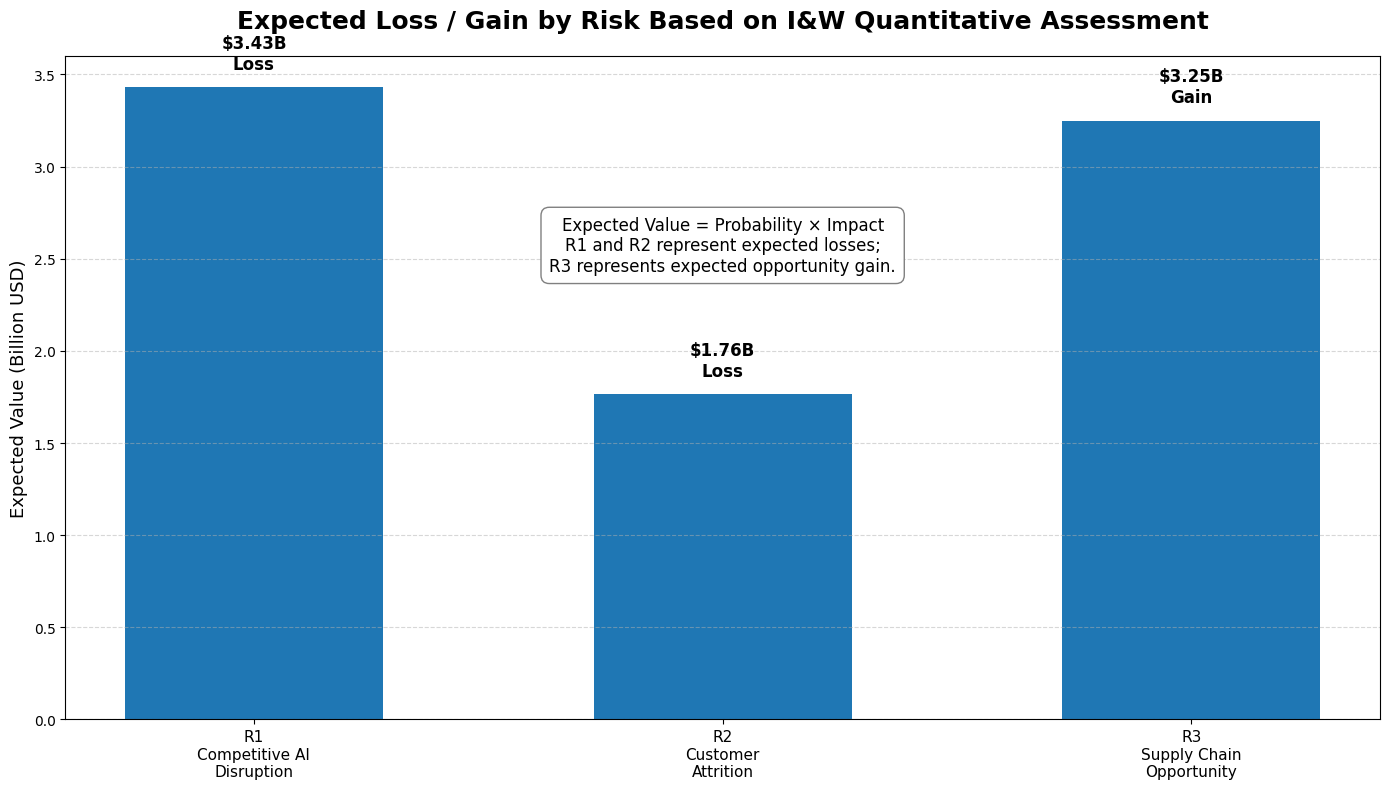

In [15]:
# Visualization: Expected Loss / Gain Comparison

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.bar(
    risk_summary["Risk_ID"],
    risk_summary["Expected_Value_Billion_USD"],
    width=0.55
)

# Data labels
for bar, value, risk_type in zip(
    bars,
    risk_summary["Expected_Value_Billion_USD"],
    risk_summary["Type"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"${value:.2f}B\n{risk_type}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Add risk names under the x-axis
ax.set_xticks(range(len(risk_summary["Risk_ID"])))
ax.set_xticklabels(
    [
        "R1\nCompetitive AI\nDisruption",
        "R2\nCustomer\nAttrition",
        "R3\nSupply Chain\nOpportunity"
    ],
    fontsize=11
)

ax.set_ylabel("Expected Value (Billion USD)", fontsize=13)
ax.set_title(
    "Expected Loss / Gain by Risk Based on I&W Quantitative Assessment",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

# Interpretation box
ax.text(
    1,
    max(risk_summary["Expected_Value_Billion_USD"]) * 0.75,
    "Expected Value = Probability × Impact\nR1 and R2 represent expected losses;\nR3 represents expected opportunity gain.",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)

plt.tight_layout()
plt.show()

Monte Carlo

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Monte Carlo settings
n_simulations = 10000

monte_carlo_inputs = {
    "R1 Competitive AI Disruption": {
        "probability": 0.35,
        "impact": 9.8,
        "type": "Loss"
    },
    "R2 Customer Attrition": {
        "probability": 0.42,
        "impact": 4.2,
        "type": "Loss"
    },
    "R3 Supply Chain Opportunity": {
        "probability": 0.65,
        "impact": 5.0,
        "type": "Gain"
    }
}

simulation_results = {}

for risk, values in monte_carlo_inputs.items():
    p_mean = values["probability"]
    i_mean = values["impact"]
    
    # Probability varied within ±20%
    simulated_probability = np.random.normal(
        loc=p_mean,
        scale=p_mean * 0.20,
        size=n_simulations
    )
    
    simulated_probability = np.clip(simulated_probability, 0, 1)
    
    # Impact varied within ±20%
    simulated_impact = np.random.normal(
        loc=i_mean,
        scale=i_mean * 0.20,
        size=n_simulations
    )
    
    simulated_impact = np.clip(simulated_impact, 0, None)
    
    simulated_value = simulated_probability * simulated_impact
    
    simulation_results[risk] = simulated_value

# Convert to DataFrame
mc_df = pd.DataFrame(simulation_results)

mc_summary = pd.DataFrame({
    "Risk": mc_df.columns,
    "Mean": mc_df.mean().values,
    "P10": mc_df.quantile(0.10).values,
    "P50": mc_df.quantile(0.50).values,
    "P90": mc_df.quantile(0.90).values
})

mc_summary

,Risk,Mean,P10,P50,P90
0,R1 Competitive AI Disruption,3.436636,2.242809,3.364556,4.737138
1,R2 Customer Attrition,1.757116,1.142969,1.722232,2.421887
2,R3 Supply Chain Opportunity,3.253420,2.109881,3.192900,4.477479


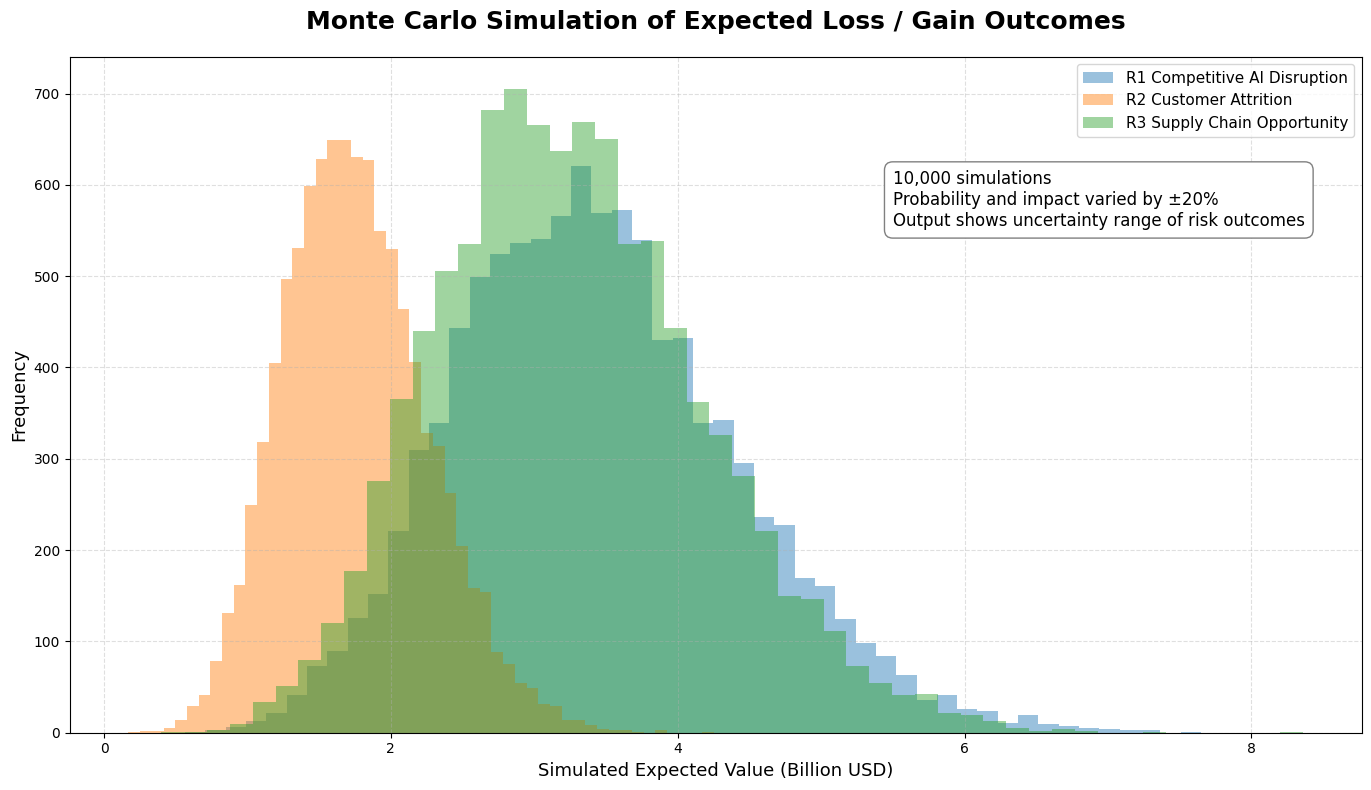

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))

for column in mc_df.columns:
    ax.hist(
        mc_df[column],
        bins=50,
        alpha=0.45,
        label=column
    )

ax.set_title(
    "Monte Carlo Simulation of Expected Loss / Gain Outcomes",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Simulated Expected Value (Billion USD)", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=11)

# Annotation box
ax.text(
    5.5,
    ax.get_ylim()[1] * 0.75,
    "10,000 simulations\nProbability and impact varied by ±20%\nOutput shows uncertainty range of risk outcomes",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)

plt.tight_layout()
plt.show()

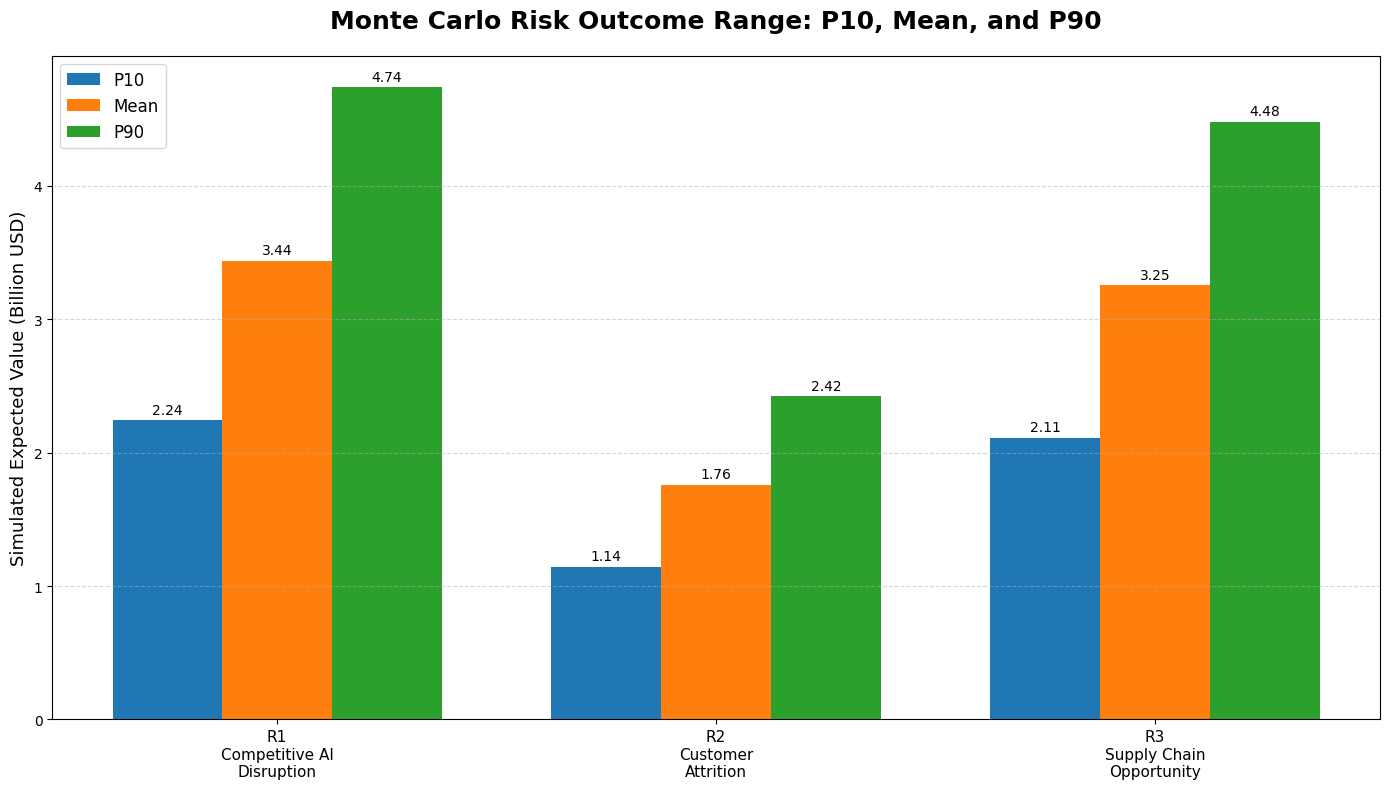

In [18]:
fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(mc_summary))
width = 0.25

ax.bar(
    [i - width for i in x],
    mc_summary["P10"],
    width=width,
    label="P10"
)

ax.bar(
    x,
    mc_summary["Mean"],
    width=width,
    label="Mean"
)

ax.bar(
    [i + width for i in x],
    mc_summary["P90"],
    width=width,
    label="P90"
)

ax.set_xticks(x)
ax.set_xticklabels(
    ["R1\nCompetitive AI\nDisruption", "R2\nCustomer\nAttrition", "R3\nSupply Chain\nOpportunity"],
    fontsize=11
)

ax.set_ylabel("Simulated Expected Value (Billion USD)", fontsize=13)
ax.set_title(
    "Monte Carlo Risk Outcome Range: P10, Mean, and P90",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=12)

# Data labels
for i, row in mc_summary.iterrows():
    ax.text(i - width, row["P10"] + 0.05, f"{row['P10']:.2f}", ha="center", fontsize=10)
    ax.text(i, row["Mean"] + 0.05, f"{row['Mean']:.2f}", ha="center", fontsize=10)
    ax.text(i + width, row["P90"] + 0.05, f"{row['P90']:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

Random Forest

In [19]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

# Scenario-based I&W dataset
rf_data = pd.DataFrame({
    "Market_Share_Gap": np.random.normal(34, 3, n),
    "Customer_Loyalty_Gap": np.random.normal(150, 30, n),
    "Inventory_Turnover": np.random.normal(9.0, 0.8, n),
    "Competitor_AI_Pressure": np.random.normal(75, 10, n),
    "Revenue_Exposure": np.random.normal(6.0, 2.0, n)
})

# Risk scoring logic based on warning thresholds
def classify_warning_status(row):
    score = 0
    
    if row["Market_Share_Gap"] > 35:
        score += 1
    if row["Customer_Loyalty_Gap"] > 160:
        score += 1
    if row["Inventory_Turnover"] < 8.5:
        score += 1
    if row["Competitor_AI_Pressure"] > 80:
        score += 1
    if row["Revenue_Exposure"] > 7:
        score += 1
    
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

rf_data["Warning_Status"] = rf_data.apply(classify_warning_status, axis=1)

rf_data.head()

,Market_Share_Gap,Customer_Loyalty_Gap,Inventory_Turnover,Competitor_AI_Pressure,Revenue_Exposure,Warning_Status
0,35.490142,177.785326,10.119484,82.783611,4.649643,Medium
1,33.585207,207.282499,9.739707,69.488143,5.710963,Low
2,35.943066,108.042973,9.047704,66.818011,4.415160,Low
3,38.569090,166.889077,8.482451,74.966255,5.384077,Medium
4,33.297540,130.480723,9.558579,73.298154,2.212771,Low


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = rf_data[
    [
        "Market_Share_Gap",
        "Customer_Loyalty_Gap",
        "Inventory_Turnover",
        "Competitor_AI_Pressure",
        "Revenue_Exposure"
    ]
]

y = rf_data["Warning_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 3))
print(classification_report(y_test, y_pred))

Model Accuracy: 0.936
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         5
         Low       0.98      0.97      0.98        61
      Medium       0.89      0.98      0.94        59

    accuracy                           0.94       125
   macro avg       0.63      0.65      0.64       125
weighted avg       0.90      0.94      0.92       125



C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classif

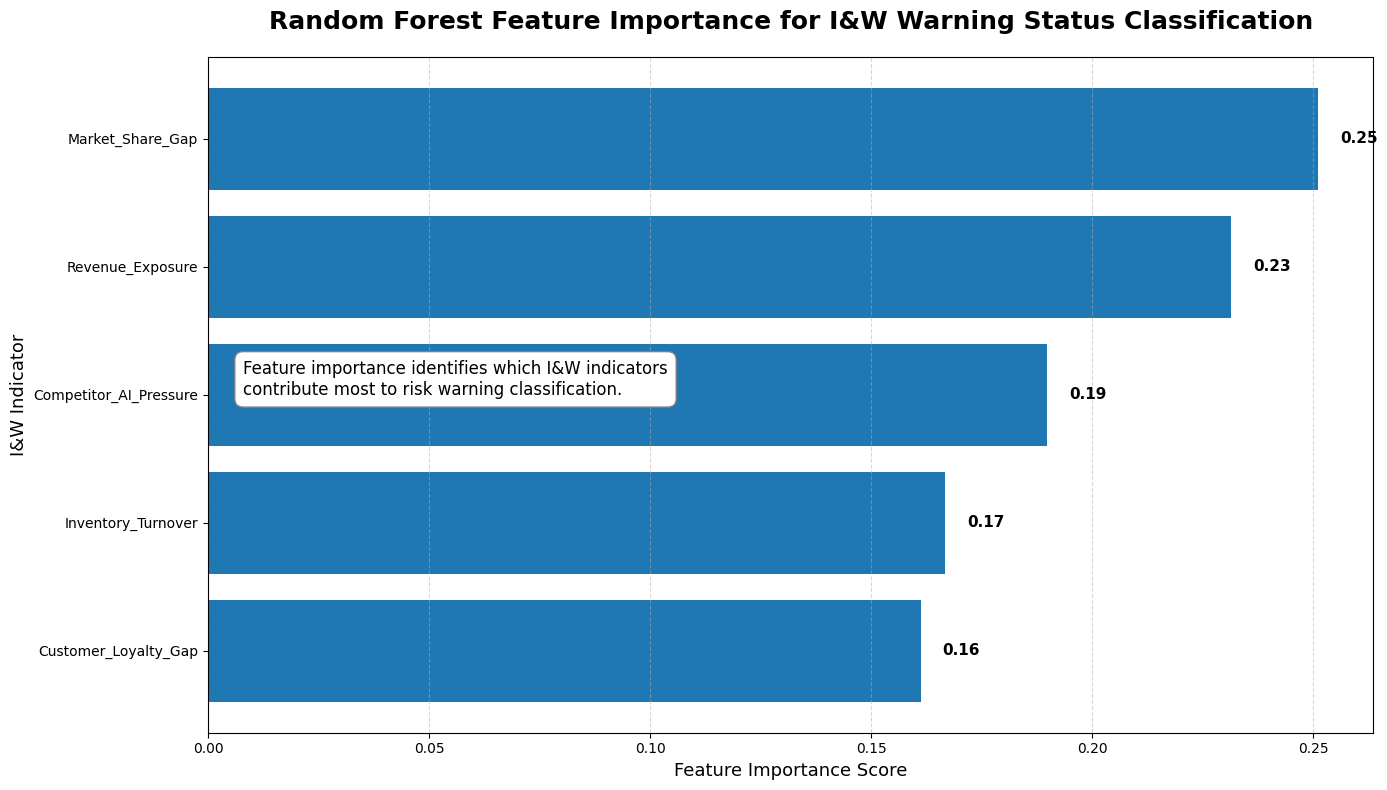

In [21]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

# Data labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Random Forest Feature Importance for I&W Warning Status Classification",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Feature Importance Score", fontsize=13)
ax.set_ylabel("I&W Indicator", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Annotation box
ax.text(
    0.03,
    0.5,
    "Feature importance identifies which I&W indicators\ncontribute most to risk warning classification.",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)

plt.tight_layout()
plt.show()

In [22]:
# Current risk scenarios based on your report assumptions
current_risks = pd.DataFrame({
    "Risk_ID": ["R1", "R2", "R3"],
    "Market_Share_Gap": [34.5, 30.0, 25.0],
    "Customer_Loyalty_Gap": [150, 175, 100],
    "Inventory_Turnover": [8.8, 8.7, 9.5],
    "Competitor_AI_Pressure": [82, 78, 65],
    "Revenue_Exposure": [9.8, 4.2, 5.0]
})

risk_features = current_risks[
    [
        "Market_Share_Gap",
        "Customer_Loyalty_Gap",
        "Inventory_Turnover",
        "Competitor_AI_Pressure",
        "Revenue_Exposure"
    ]
]

predicted_status = rf_model.predict(risk_features)
predicted_prob = rf_model.predict_proba(risk_features)

prob_df = pd.DataFrame(
    predicted_prob,
    columns=rf_model.classes_
)

prob_df.insert(0, "Risk_ID", current_risks["Risk_ID"])
prob_df["Predicted_Status"] = predicted_status

prob_df

,Risk_ID,High,Low,Medium,Predicted_Status
0,R1,0.028330,0.241417,0.730253,Medium
1,R2,0.000159,0.888174,0.111668,Low
2,R3,0.000000,0.954088,0.045912,Low


C:\Users\user\AppData\Local\Temp\ipykernel_30332\3891749577.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


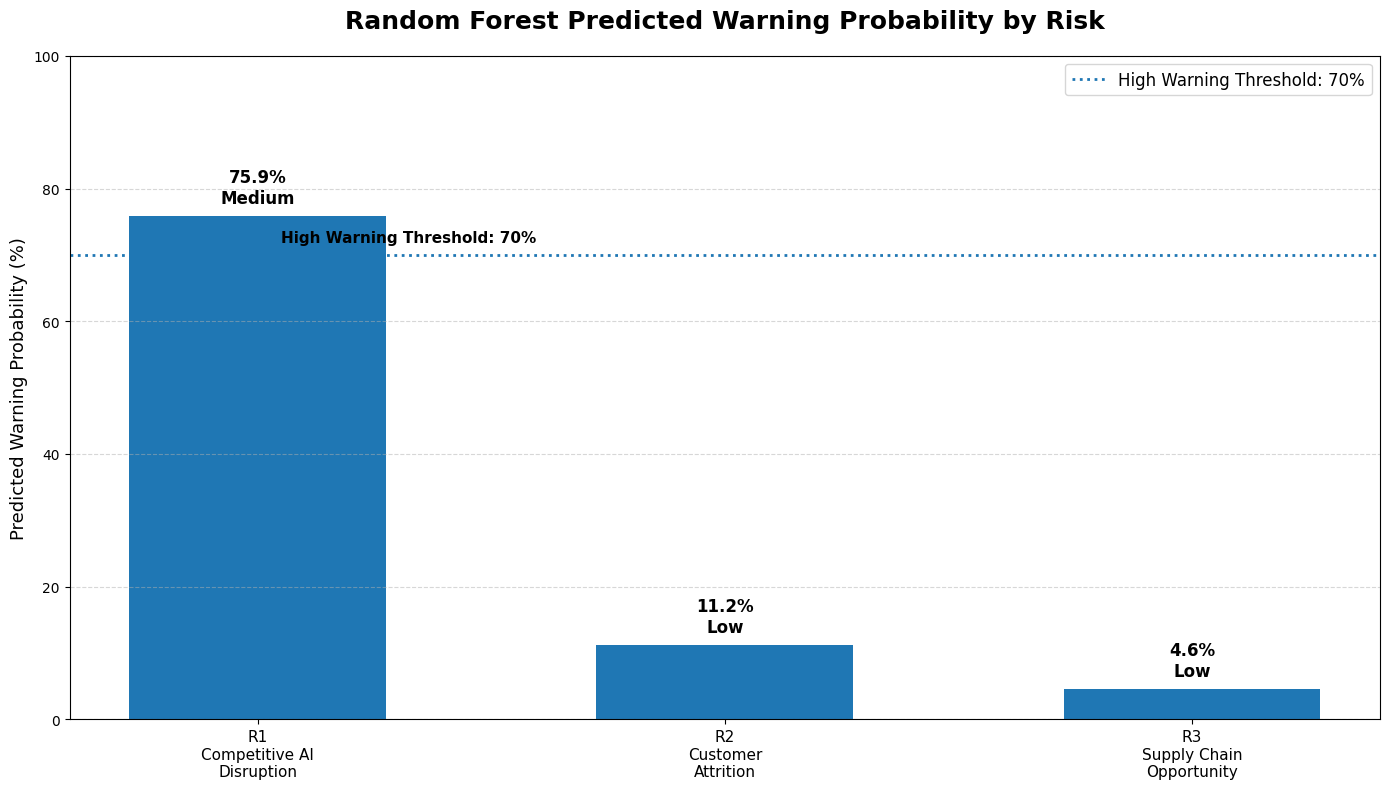

In [23]:
# Select probability of Medium + High as warning probability
prob_df["Warning_Probability"] = prob_df.get("Medium", 0) + prob_df.get("High", 0)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.bar(
    prob_df["Risk_ID"],
    prob_df["Warning_Probability"] * 100,
    width=0.55
)

for bar, value, status in zip(
    bars,
    prob_df["Warning_Probability"] * 100,
    prob_df["Predicted_Status"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.1f}%\n{status}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xticks(range(len(prob_df["Risk_ID"])))
ax.set_xticklabels(
    [
        "R1\nCompetitive AI\nDisruption",
        "R2\nCustomer\nAttrition",
        "R3\nSupply Chain\nOpportunity"
    ],
    fontsize=11
)

ax.axhline(
    y=70,
    linestyle=":",
    linewidth=2,
    label="High Warning Threshold: 70%"
)

ax.text(
    0.05,
    72,
    "High Warning Threshold: 70%",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel("Predicted Warning Probability (%)", fontsize=13)
ax.set_ylim(0, 100)

ax.set_title(
    "Random Forest Predicted Warning Probability by Risk",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()